# Fig 6: whole-brain projection

Extra-insula electrodes projected onto the frozen insula concat-NMF templates (sensory / sustained / motor). The map is waveform similarity, not connectivity.

Locked view: focused pial territories, top 50% of eligible vertices. Code moved from `notebooks/wholebrain_projection_explore.ipynb`. Surface cache stays in `results/nmf/whole_brain_projection/visualization/surface_motif_maps_focused.npz`.

SVGs write to `img/fig6/`. The 31 Aug–4 Sep renders remain in `img/nmf/whole_brain_projection/`.

Style: [`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md). SVG only. See `docs/NMF.md` §7.


In [15]:
%matplotlib inline

from __future__ import annotations

import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.nmf.waveform_analysis as waveform_analysis
import src.nmf.whole_brain_projection_viz as whole_brain_projection_viz

importlib.reload(waveform_analysis)
importlib.reload(whole_brain_projection_viz)

from src.nmf.waveform_analysis import CLUSTER_LABELS, CLUSTER_ORDER, FUNCTION_COLORS
from src.nmf.whole_brain_projection_viz import (
    combined_focused_rgba,
    offset_vertices_along_normals,
    retain_largest_surface_clusters,
    surface_label_boundary_edges,
)
from src.paths import img_dir, nmf_wholebrain_dir, save_svg


In [ ]:
from matplotlib import font_manager

for _ttf in (Path(sys.prefix) / "fonts").glob("arial*.ttf"):
    font_manager.fontManager.addfont(str(_ttf))

cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
fontsize = 7

RECON_DIR = Path("/cwork/ns458/ECoG_Recon")
TEMPLATE_SUBJECT = "cvs_avg35_inMNI152"
COMPONENTS = tuple(CLUSTER_ORDER)
COMPONENT_LABELS = dict(CLUSTER_LABELS)
LANDMARK_ROIS = (
    ("HG", "transversetemporal", "#111111"),
    ("STG", "superiortemporal", "#1B4332"),
    ("PrG", "precentral", "#1D3557"),
    ("PoG", "postcentral", "#6B3F2A"),
    ("Insula", "insula", "#4A4A4A"),
)
OVERLAY_NORMAL_OFFSET_MM = 0.5
OUTLINE_NORMAL_OFFSET_MM = 0.7
KEEP_TOP = 0.50
FOCUSED_MIN_SUBJECTS = 3
FOCUSED_POSITIVE_FRACTION = 0.50
FOCUSED_MAX_CLUSTERS = 5
FOCUSED_MIN_CLUSTER_VERTICES = 20

CACHE = nmf_wholebrain_dir() / "visualization" / "surface_motif_maps_focused.npz"
FIG_DIR = img_dir("fig6")
PIAL = (
    FIG_DIR
    / f"wholebrain_surface_motifs_focused_combined_pial_top{int(round(KEEP_TOP * 100))}.svg"
)
APARC_SVG = FIG_DIR / "wholebrain_surface_motifs_focused_aparc_share.svg"

print("cache", CACHE)
print("out", PIAL)
print("aparc", APARC_SVG)
print("FUNCTION_COLORS", FUNCTION_COLORS)

cache /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/whole_brain_projection/visualization/surface_motif_maps_focused.npz
out /hpc/group/coganlab/nanlinshi/insula-functional/img/fig6/wholebrain_surface_motifs_focused_combined_pial_top50.svg
aparc /hpc/group/coganlab/nanlinshi/insula-functional/img/fig6/wholebrain_surface_motifs_focused_aparc_share.svg
FUNCTION_COLORS {'sustain': '#C4A35A', 'motor': '#A9373B', 'sensory': '#2369BD'}


In [17]:
def add_rgba_overlay(brain, hemi: str, rgba: np.ndarray) -> None:
    import pyvista as pv

    coords = np.asarray(brain.geo[hemi].coords, dtype=float)
    faces = np.asarray(brain.geo[hemi].faces, dtype=np.int64)
    if len(coords) != len(rgba):
        raise ValueError(
            f"{hemi} overlay length {len(rgba)} does not match mesh {len(coords)}"
        )
    visible = np.asarray(rgba[:, 3], dtype=float) > 1e-6
    keep = visible[faces].any(axis=1)
    if not keep.any():
        return
    lifted = offset_vertices_along_normals(coords, faces, OVERLAY_NORMAL_OFFSET_MM)
    cells = np.hstack(
        [np.full((int(keep.sum()), 1), 3, dtype=np.int64), faces[keep]]
    ).ravel()
    mesh = pv.PolyData(lifted, cells)
    mesh["rgba"] = (np.clip(rgba, 0.0, 1.0) * 255.0).astype(np.uint8)
    brain._renderer.plotter.add_mesh(
        mesh,
        scalars="rgba",
        rgba=True,
        lighting=False,
        smooth_shading=True,
    )


def aparc_label_map(hemi: str) -> dict[str, object]:
    import mne

    labels = mne.read_labels_from_annot(
        TEMPLATE_SUBJECT,
        parc="aparc",
        subjects_dir=str(RECON_DIR),
        hemi=hemi,
    )
    return {label.name.rsplit("-", 1)[0]: label for label in labels}


def add_landmark_outlines(brain, hemi: str) -> None:
    import pyvista as pv

    coords = np.asarray(brain.geo[hemi].coords, dtype=float)
    faces = np.asarray(brain.geo[hemi].faces, dtype=np.int64)
    lifted = offset_vertices_along_normals(coords, faces, OUTLINE_NORMAL_OFFSET_MM)
    labels = aparc_label_map(hemi)
    for _, aparc_name, color in LANDMARK_ROIS:
        label = labels.get(aparc_name)
        if label is None:
            continue
        mask = np.zeros(len(coords), dtype=bool)
        vertices = np.asarray(label.vertices, dtype=int)
        valid = (vertices >= 0) & (vertices < len(coords))
        mask[vertices[valid]] = True
        edges = surface_label_boundary_edges(faces, mask)
        if len(edges) == 0:
            continue
        cells = np.empty(len(edges) * 3, dtype=np.int64)
        cells[0::3] = 2
        cells[1::3] = edges[:, 0]
        cells[2::3] = edges[:, 1]
        mesh = pv.PolyData()
        mesh.points = lifted
        mesh.lines = cells
        brain._renderer.plotter.add_mesh(
            mesh,
            color=color,
            line_width=2.4,
            lighting=False,
            render_lines_as_tubes=False,
        )


def render_hemisphere(payload, hemi, thresholds, value_max, surf="pial"):
    import mne
    from mne.viz import Brain

    brain = Brain(
        TEMPLATE_SUBJECT,
        subjects_dir=str(RECON_DIR),
        surf=surf,
        hemi=hemi,
        background="white",
        show=False,
        cortex=(0.88, 0.88, 0.88),
        alpha=1.0,
        size=(550, 450),
    )
    add_rgba_overlay(
        brain,
        hemi,
        combined_focused_rgba(payload, hemi, thresholds, value_max),
    )
    add_landmark_outlines(brain, hemi)
    distance = 450.0 if surf == "pial" else 550.0
    images = {}
    for view in ("lateral", "medial"):
        brain.show_view(view=view, distance=distance)
        images[view] = brain.screenshot(mode="rgb")
    brain.close()
    return images


CORTEX_GRAY = np.array([0.88, 0.88, 0.88])


def overlay_colormap(hex_color, n: int = 256):
    """Match combined_focused_rgba: hue over gray cortex, alpha 0.40→1."""
    import matplotlib.colors as mcolors

    rgb = np.asarray(mcolors.to_rgb(hex_color), dtype=float)
    fraction = np.linspace(0.0, 1.0, n)
    intensity = 0.40 + 0.60 * fraction
    colors = intensity[:, None] * rgb[None, :] + (1.0 - intensity)[:, None] * CORTEX_GRAY
    return mcolors.LinearSegmentedColormap.from_list("motif_overlay", colors)


def refocus_payload(payload, keep_top: float = KEEP_TOP):
    """Rebuild display masks from the cached maps at a new keep-top fraction."""
    import mne

    if not 0.0 < keep_top <= 1.0:
        raise ValueError("keep_top must be in (0, 1]")
    surface_quantile = 1.0 - keep_top
    faces_by_hemi = {}
    for hemi in ("lh", "rh"):
        _, faces = mne.read_surface(
            str(RECON_DIR / TEMPLATE_SUBJECT / "surf" / f"{hemi}.pial")
        )
        faces_by_hemi[hemi] = faces

    thresholds = {}
    for component in COMPONENTS:
        eligible_parts = []
        for hemi in ("lh", "rh"):
            data = np.asarray(payload[f"{hemi}_{component}_specificity"], dtype=float)
            coverage = np.asarray(payload[f"{hemi}_{component}_coverage"])
            positive_fraction = np.asarray(
                payload[f"{hemi}_{component}_positive_fraction"]
            )
            eligible = (
                (coverage >= FOCUSED_MIN_SUBJECTS)
                & (positive_fraction >= FOCUSED_POSITIVE_FRACTION)
                & np.isfinite(data)
                & (data > 0)
            )
            eligible_parts.append(data[eligible])
        combined = np.concatenate(eligible_parts)
        thresholds[component] = (
            float(np.quantile(combined, surface_quantile)) if len(combined) else np.inf
        )
        for hemi in ("lh", "rh"):
            data = np.asarray(payload[f"{hemi}_{component}_specificity"], dtype=float)
            coverage = np.asarray(payload[f"{hemi}_{component}_coverage"])
            positive_fraction = np.asarray(
                payload[f"{hemi}_{component}_positive_fraction"]
            )
            candidate = (
                (coverage >= FOCUSED_MIN_SUBJECTS)
                & (positive_fraction >= FOCUSED_POSITIVE_FRACTION)
                & np.isfinite(data)
                & (data >= thresholds[component])
            )
            payload[f"{hemi}_{component}_display_mask"] = retain_largest_surface_clusters(
                candidate,
                faces_by_hemi[hemi],
                max_clusters=FOCUSED_MAX_CLUSTERS,
                min_vertices=FOCUSED_MIN_CLUSTER_VERTICES,
            )
    payload["display_thresholds"] = np.array(
        [thresholds[name] for name in COMPONENTS]
    )
    return payload, thresholds


def add_specificity_colorbar(fig, vmin: float, vmax: float) -> None:
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors

    axis = fig.add_axes([0.30, 0.02, 0.40, 0.025])
    cmap = overlay_colormap("#222222")
    norm = mcolors.Normalize(vmin=vmin, vmax=max(vmax, vmin + 1e-6))
    handle = cm.ScalarMappable(norm=norm, cmap=cmap)
    handle.set_array([])
    colorbar = fig.colorbar(handle, cax=axis, orientation="horizontal")
    colorbar.set_ticks([vmin, vmax])
    colorbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])
    colorbar.set_label("specificity", fontsize=7, labelpad=2)
    colorbar.ax.tick_params(labelsize=6, width=0.6, length=2)
    colorbar.outline.set_linewidth(0.6)



## Focused territories on pial


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig6/fig6_nmf_templates_nogo.svg


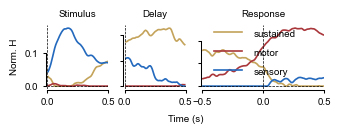

In [18]:
import pandas as pd
import seaborn as sns

H_PATH = Path("/work/ns458/nmf_nogo_window_test/results/H_by_phase.csv")

PHASES = ["stimulus", "delay", "response"]
HUE_ORDER = [CLUSTER_LABELS[c] for c in COMPONENTS]
PALETTE = {CLUSTER_LABELS[c]: FUNCTION_COLORS[c] for c in COMPONENTS}
PHASE_XLIMS = {
    "stimulus": (0.0, 0.5),
    "delay": (0.0, 0.5),
    "response": (-0.5, 0.5),
}
PHASE_XTICKS = {
    "stimulus": (0.0, 0.5),
    "delay": (0.0, 0.5),
    "response": (-0.5, 0.0, 0.5),
}

H_by_phase = pd.read_csv(H_PATH)
H_by_phase = H_by_phase[H_by_phase["functional_cluster"].isin(COMPONENTS)].copy()
H_by_phase["cluster_label"] = H_by_phase["functional_cluster"].map(CLUSTER_LABELS)

width_ratios = [hi - lo for lo, hi in (PHASE_XLIMS[phase] for phase in PHASES)]
fig = plt.figure(figsize=(8 * cm, 3 * cm))
gs = fig.add_gridspec(
    nrows=1,
    ncols=len(PHASES),
    width_ratios=width_ratios,
    wspace=0.2,
    left=0.10,
    right=0.98,
    bottom=0.28,
    top=0.82,
)
axes = [fig.add_subplot(gs[0, j]) for j in range(len(PHASES))]

for ax, phase in zip(axes, PHASES):
    lo, hi = PHASE_XLIMS[phase]
    phase_df = H_by_phase.loc[
        (H_by_phase["phase"] == phase)
        & (H_by_phase["time"] >= lo)
        & (H_by_phase["time"] <= hi)
    ]
    sns.lineplot(
        data=phase_df,
        x="time",
        y="normalized_H",
        hue="cluster_label",
        hue_order=HUE_ORDER,
        ax=ax,
        palette=PALETTE,
        legend=ax is axes[-1],
        lw=1.2,
        errorbar=None,
    )
    ax.set_xlim(lo, hi)
    ax.set_xticks(PHASE_XTICKS[phase])
    ax.set_xlabel("")
    ax.set_title(phase.capitalize(), fontsize=fontsize)
    ax.axvline(0, color="k", linestyle="--", linewidth=0.5)
    ax.axhline(0, color="k", linestyle="--", linewidth=0.5)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    if ax is axes[0]:
        ax.set_ylabel("Norm. H", fontsize=fontsize)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

legend = axes[-1].get_legend()
if legend is not None:
    legend.set_title("")
    for text in legend.get_texts():
        text.set_fontsize(fontsize)
    legend.set_frame_on(False)

fig.text(0.54, 0.06, "Time (s)", ha="center", va="top", fontsize=fontsize)
out = save_svg(fig, FIG_DIR / "fig6_nmf_templates_nogo")
print("Wrote", out)
plt.show()

libEGL warning: pci id for fd 99: 10de:26b2, driver (null)

pci id for fd 100: 10de:26b2, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 99: 10de:26b2, driver (null)

pci id for fd 100: 10de:26b2, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-09-22 19:46:17.194 (13196.064s) [    7F4A7E602740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x12f4e670): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: pci id for fd 99: 10de:26b2, driver (null)

pci id for fd 100: 10de:26b2, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 99: 10de:26b2, driver (null)

pci id for fd 100: 10de:26b2, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/

Reading labels from parcellation...
   read 34 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.annot


libEGL warning: pci id for fd 99: 10de:26b2, driver (null)

pci id for fd 100: 10de:26b2, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 99: 10de:26b2, driver (null)

pci id for fd 100: 10de:26b2, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-09-22 19:46:18.060 (13196.930s) [    7F4A7E602740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x646ee30): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: pci id for fd 99: 10de:26b2, driver (null)

pci id for fd 100: 10de:26b2, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 99: 10de:26b2, driver (null)

pci id for fd 100: 10de:26b2, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/d

Reading labels from parcellation...
   read 34 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.annot
keep top 50% of eligible vertices
per-motif floors: {'sustained': '0.114', 'motor': '0.162', 'sensory': '0.099'}
colorbar 0.099 → 0.471
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig6/wholebrain_surface_motifs_focused_combined_pial_top50.svg


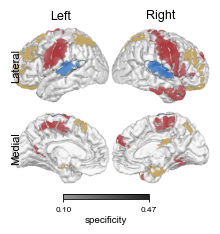

In [19]:
import mne

if not CACHE.exists():
    raise FileNotFoundError(CACHE)

with np.load(CACHE) as raw:
    payload = {key: raw[key] for key in raw.files}
payload, thresholds = refocus_payload(payload, keep_top=KEEP_TOP)
value_max = float(np.asarray(payload["display_value_max"]).reshape(-1)[0])
vmin = float(np.min([thresholds[name] for name in COMPONENTS]))

mne.viz.set_3d_backend("notebook")
views = (("lateral", "Lateral"), ("medial", "Medial"))
hemis = (("lh", "Left"), ("rh", "Right"))
screenshots = {
    hemi: render_hemisphere(payload, hemi, thresholds, value_max, surf="pial")
    for hemi, _ in hemis
}


def _crop_brain(img, pad=6):
    rgb = np.asarray(img)
    mask = np.any(rgb < 250, axis=-1)
    if not mask.any():
        return rgb
    ys, xs = np.nonzero(mask)
    y0 = max(0, int(ys.min()) - pad)
    y1 = min(rgb.shape[0], int(ys.max()) + 1 + pad)
    x0 = max(0, int(xs.min()) - pad)
    x1 = min(rgb.shape[1], int(xs.max()) + 1 + pad)
    return rgb[y0:y1, x0:x1]


fig, axes = plt.subplots(2, 2, figsize=(5.43 * cm, 4.80 * cm))
for row, (view, view_label) in enumerate(views):
    for column, (hemi, hemi_label) in enumerate(hemis):
        axes[row, column].imshow(_crop_brain(screenshots[hemi][view]))
        axes[row, column].axis("off")
        if row == 0:
            axes[row, column].set_title(hemi_label, fontsize=9)
        if column == 0:
            axes[row, column].text(
                0.01,
                0.5,
                view_label,
                transform=axes[row, column].transAxes,
                rotation=90,
                va="center",
                fontsize=8,
            )

fig.subplots_adjust(
    left=0.05, right=0.99, top=0.94, bottom=0.07, wspace=0.0, hspace=0.0
)
add_specificity_colorbar(fig, vmin, value_max)

print(f"keep top {KEEP_TOP:.0%} of eligible vertices")
print(
    "per-motif floors:",
    {CLUSTER_LABELS[name]: f"{thresholds[name]:.3f}" for name in COMPONENTS},
)
print(f"colorbar {vmin:.3f} → {value_max:.3f}")
save_svg(fig, PIAL, close=False)
print(f"Wrote {PIAL}")
plt.show()

## What each color sits on

Count held-out electrodes whose nearest pial vertex falls in the same
winner-take-all patches as the brain. Bars are raw electrode counts in
Hammers ROIs; insula (AIC/PIC) omitted; top four ROIs per motif.



Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/fig6/wholebrain_surface_motifs_focused_aparc_share.svg
in patch (no insula): 1328 electrodes
sensory: STGp 211, pTL 62, SMG 18, SPL 3, others 0
sustained: MFG 212, OFC 161, SFG 36, Amyg 33, others 124
motor: PrG 183, PoG 113, SMG 36, TP 22, others 114


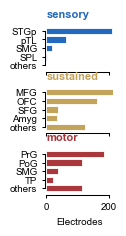

In [20]:
import pandas as pd
import seaborn as sns

from src.nmf.oaec_focused_overlay import assign_focused_membership, focused_mask_payload
from src.nmf.whole_brain_projection_viz import prepare_projection_frame
from src.paths import nmf_wholebrain_dir

APARC_SVG = FIG_DIR / "wholebrain_surface_motifs_focused_aparc_share.svg"
INSULA_ROIS = {"AIC", "PIC", "Insula", "insula"}
MAX_DISTANCE_MM = 15.0
TOP_N = 4
PLOT_ORDER = ("sensory", "sustain", "motor")


if "payload" not in globals():
    if not CACHE.exists():
        raise FileNotFoundError(CACHE)
    with np.load(CACHE) as raw:
        payload = {key: raw[key] for key in raw.files}
    payload, thresholds = refocus_payload(payload, keep_top=KEEP_TOP)

import mne

vertices_by_hemi = {}
for hemi in ("lh", "rh"):
    vertices, _ = mne.read_surface(
        str(RECON_DIR / TEMPLATE_SUBJECT / "surf" / f"{hemi}.pial")
    )
    vertices_by_hemi[hemi] = vertices

electrodes = prepare_projection_frame(
    pd.read_csv(nmf_wholebrain_dir() / "electrode_projection.csv")
)
mask_by_hemi, specificity_by_hemi = focused_mask_payload(
    payload, components=COMPONENTS
)
marked = assign_focused_membership(
    electrodes,
    vertices_by_hemi=vertices_by_hemi,
    mask_by_hemi=mask_by_hemi,
    specificity_by_hemi=specificity_by_hemi,
    components=COMPONENTS,
    max_distance=MAX_DISTANCE_MM,
)
in_patch = marked.loc[
    marked["in_focused"].eq(True)
    & marked["focused_component"].notna()
    & ~marked["roi"].astype(str).isin(INSULA_ROIS)
].copy()
counts = (
    in_patch.groupby(["focused_component", "roi"], observed=True)
    .size()
    .rename("n")
    .reset_index()
)
keep = []
for component in PLOT_ORDER:
    subset = counts.loc[counts["focused_component"].eq(component)].sort_values(
        "n", ascending=False
    )
    top = subset.head(TOP_N).copy()
    rest = subset.iloc[TOP_N:]
    other_n = int(rest["n"].sum()) if len(rest) else 0
    top = pd.concat(
        [
            top,
            pd.DataFrame(
                {
                    "focused_component": [component],
                    "roi": ["others"],
                    "n": [other_n],
                }
            ),
        ],
        ignore_index=True,
    )
    keep.append(top)
plot_frame = pd.concat(keep, ignore_index=True)

fig, axes = plt.subplots(3, 1, figsize=(2.65 * cm, 4.84 * cm), sharex=True)
xmax = max(10, int(plot_frame["n"].max()) + 2)
for ax, component in zip(axes, PLOT_ORDER):
    subset = plot_frame.loc[plot_frame["focused_component"].eq(component)].iloc[::-1]
    ax.barh(
        subset["roi"],
        subset["n"],
        color=FUNCTION_COLORS[component],
        height=0.72,
        edgecolor="white",
        linewidth=0.6,
    )
    ax.set_title(
        CLUSTER_LABELS[component],
        color=FUNCTION_COLORS[component],
        fontsize=8,
        fontweight="bold",
        loc="left",
    )
    ax.set_xlim(0, xmax)
    ax.tick_params(labelsize=7, width=0.75, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
axes[-1].set_xlabel("Electrodes", fontsize=7)
fig.subplots_adjust(left=0.32, right=0.96, top=0.96, bottom=0.08, hspace=0.38)
save_svg(fig, APARC_SVG, close=False)
print(f"Wrote {APARC_SVG}")
print(f"in patch (no insula): {len(in_patch)} electrodes")
for component in PLOT_ORDER:
    subset = plot_frame.loc[plot_frame["focused_component"].eq(component)]
    summary = ", ".join(f"{row.roi} {int(row.n)}" for row in subset.itertuples())
    print(f"{CLUSTER_LABELS[component]}: {summary}")
plt.show()